In [1]:
!pip install qsprpred


In [1]:

import os
import qsprpred

from qsprpred.extra.gpu.models.neural_network import STFullyConnected

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP

os.makedirs("tutorial_output_test/data", exist_ok=True)

# Create dataset
dataset = QSPRDataset.fromTableFile(
    filename="../../../../tutorials/tutorial_data/A2A_LIGANDS.tsv",
    store_dir="tutorial_output_test/data",
    name="MonitoringTutorialDataset",
    target_props=[{"name": "pchembl_value_Mean", "task": "SINGLECLASS", "th": [6.5]}],
    random_state=42
)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
display(dataset.df)

,SMILES,pchembl_value_Mean,Year,QSPRID,pchembl_value_Mean_original
QSPRID,,,,,
MonitoringTutorialDataset_0000,Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...,True,2008.0,MonitoringTutorialDataset_0000,8.68
MonitoringTutorialDataset_0001,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...,False,2010.0,MonitoringTutorialDataset_0001,4.82
MonitoringTutorialDataset_0002,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,False,2009.0,MonitoringTutorialDataset_0002,5.65
MonitoringTutorialDataset_0003,CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...,False,2009.0,MonitoringTutorialDataset_0003,5.45
MonitoringTutorialDataset_0004,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,False,2019.0,MonitoringTutorialDataset_0004,5.20
...,...,...,...,...,...
MonitoringTutorialDataset_4077,CNc1ncc(C(=O)NCc2ccc(OC)cc2)c2nc(-c3ccco3)nn12,True,2018.0,MonitoringTutorialDataset_4077,7.09
MonitoringTutorialDataset_4078,Nc1nc(-c2ccco2)c2ncn(C(=O)NCCc3ccccc3)c2n1,True,2008.0,MonitoringTutorialDataset_4078,8.22
MonitoringTutorialDataset_4079,Nc1nc(Nc2ccc(F)cc2)nc(CSc2nnc(N)s2)n1,False,2010.0,MonitoringTutorialDataset_4079,4.89


In [3]:
# calculate compound features and split dataset into train and test
dataset.prepareDataset(
    split=RandomSplit(test_fraction=0.2, dataset=dataset),
    feature_calculators=[MorganFP(radius=3, nBits=2048)],
    recalculate_features=True,
)

dataset.getDF().head()

,SMILES,pchembl_value_Mean,Year,QSPRID,pchembl_value_Mean_original
QSPRID,,,,,
MonitoringTutorialDataset_0000,Cc1cc(C)n(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n...,True,2008.0,MonitoringTutorialDataset_0000,8.68
MonitoringTutorialDataset_0001,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2nc3c(cc12...,False,2010.0,MonitoringTutorialDataset_0001,4.82
MonitoringTutorialDataset_0002,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,False,2009.0,MonitoringTutorialDataset_0002,5.65
MonitoringTutorialDataset_0003,CNC(=O)C12CC1C(n1cnc3c(NCc4cccc(Cl)c4)nc(C#CCC...,False,2009.0,MonitoringTutorialDataset_0003,5.45
MonitoringTutorialDataset_0004,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,False,2019.0,MonitoringTutorialDataset_0004,5.20


In [4]:
from qsprpred.data.descriptors.sets import RDKitDescs

rdkit_descs = RDKitDescs()

dataset.addDescriptors([rdkit_descs])

dataset.descriptorSets

In [5]:

display(dataset.getDF().head())
display(dataset.X)



,SMILES,pchembl_value_Mean,Year,QSPRID,pchembl_value_Mean_original
QSPRID,,,,,
MonitoringTutorialDataset_0000,Cc1cc(C)n(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n...,True,2008.0,MonitoringTutorialDataset_0000,8.68
MonitoringTutorialDataset_0001,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2nc3c(cc12...,False,2010.0,MonitoringTutorialDataset_0001,4.82
MonitoringTutorialDataset_0002,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,False,2009.0,MonitoringTutorialDataset_0002,5.65
MonitoringTutorialDataset_0003,CNC(=O)C12CC1C(n1cnc3c(NCc4cccc(Cl)c4)nc(C#CCC...,False,2009.0,MonitoringTutorialDataset_0003,5.45
MonitoringTutorialDataset_0004,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,False,2019.0,MonitoringTutorialDataset_0004,5.20


,MorganFP_MorganFP_0,MorganFP_MorganFP_1,MorganFP_MorganFP_2,MorganFP_MorganFP_3,MorganFP_MorganFP_4,MorganFP_MorganFP_5,MorganFP_MorganFP_6,MorganFP_MorganFP_7,MorganFP_MorganFP_8,MorganFP_MorganFP_9,...,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_term_acetylene,RDkit_fr_tetrazole,RDkit_fr_thiazole,RDkit_fr_thiocyan,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
MonitoringTutorialDataset_0221,False,False,False,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.569111
MonitoringTutorialDataset_3644,False,False,False,False,False,False,False,False,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.753681
MonitoringTutorialDataset_2459,False,True,False,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.070382
MonitoringTutorialDataset_1315,False,False,True,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.756204
MonitoringTutorialDataset_1017,False,False,False,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.777209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MonitoringTutorialDataset_1130,False,False,False,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.389941
MonitoringTutorialDataset_1294,False,False,False,True,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.274991
MonitoringTutorialDataset_0860,False,False,False,False,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.239563


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X1 = scaler.fit_transform(dataset.X)
X2 = scaler.transform(dataset.X_ind)

In [7]:
import pandas as pd
import numpy as np

X1 = np.nan_to_num(X1)
display(np.isnan(X1).sum())


0

In [8]:
print("Unique labels:", np.unique(dataset.y))


Unique labels: [False  True]


In [13]:
import torch
from torch import nn, optim
from torch.nn import functional as F
test_par_4 = {'weight_decay': 0.0001, 'patience': 100, 
            'neuron_layers': [5000, 2500],
            'n_epochs': 400, 'dropout_frac': 0.5,
            'act_fun': F.gelu,
             'optimizer' : optim.AdamW}
model_sts_4 = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par_4)

In [14]:

model_sts_4.fit(X1, dataset.y)

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=2258, out_features=5000, bias=True)
     (1): Linear(in_features=5000, out_features=2500, bias=True)
     (2): Linear(in_features=2500, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.5, inplace=False)
   (criterion): BCELoss()
   (final_layer_activation): Sigmoid()
 ),
 0)

In [16]:
from sklearn.metrics import f1_score
pred = model_sts_4.predict(X2)
pred = pred > 0.5
print(f1_score(pred, dataset.y_ind))

0.8493150684931506


In [9]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [6]:
from torch.nn import functional as F

print("xd")
model_sts = STFullyConnected(
    n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,
    patience=100,
    tol=1e-4,
    neuron_layers=[4000, 3000, 1000, 500, 200], #[3000, 1500, 500, 100]
    act_fun=F.selu,
    is_reg=False
)
model_sts.fit(dataset.X, dataset.y)


xd


(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=2048, out_features=4000, bias=True)
     (1): Linear(in_features=4000, out_features=3000, bias=True)
     (2): Linear(in_features=3000, out_features=1000, bias=True)
     (3): Linear(in_features=1000, out_features=500, bias=True)
     (4): Linear(in_features=500, out_features=200, bias=True)
     (5): Linear(in_features=200, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.25, inplace=False)
   (criterion): BCELoss()
   (final_layer_activation): Sigmoid()
 ),
 0)

In [ ]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
param_grid = ParameterGrid({
    "act_fun": [F.selu, F.elu, F.gelu, F.silu],
    "dropout_frac": [0, 0.05, 0.1],
    "patience": [100],
    "weight_decay": [1e-4],
    "n_epochs": [200, 350, 500],
    "neuron_layers": [[ 5000, 4096, 2048, 1024], [2048, 1024, 512, 256, 128, 64], [4096, 2048, 1024, 512, 256], [1024, 512, 256, 128, 64, 32, 16]],
})
print(len(param_grid))
i = 0
val_f1 = []
param_len = len(param_grid)
for param in param_grid:
    i += 1
    print(i, '/', param_len)
    model_sts = STFullyConnected(n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **param)
    model_sts.fit(dataset.X, dataset.y)
    res = model_sts.predict(dataset.X_ind)
    res = res >0.5
    val_f1.append(f1_score(res, dataset.y_ind))
    print(param)
    print(f1_score(res, dataset.y_ind))

In [ ]:
from sklearn.metrics import f1_score

# print(model_sts.predict(dataset.X_ind))
res = model_sts.predict(dataset.X_ind)
res = res > 0.5
print(f1_score(dataset.y_ind, res))

In [ ]:
import numpy as np


print(param_grid[np.argmax(val_f1)])
print(max(val_f1))

In [ ]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score

param_grid_2 = ParameterGrid({
    "act_fun": [F.selu, F.elu, F.silu],
    "dropout_frac": [ 0.1, 0.2, 0.3, 0.4],
    "patience": [100],
    "weight_decay": [1e-4],
    "n_epochs": [1200, 350, 200, 500],
    "neuron_layers": [[ 5000, 1024], [2048, 1024, 512, 256, 128, 64, 32, 16, 8], [4096, 2048, 1024, 512, 256], [2048, 1024, 512, 256, 128, 64], [2048, 512, 512, 512, 126, 32]]
})
print(len(param_grid_2))
i = 0
val_f1_2 = []
param_len_2 = len(param_grid_2)
for param in param_grid_2:
    i += 1
    print(i, '/', param_len_2)
    model_sts_2 = STFullyConnected(n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **param)
    model_sts_2.fit(dataset.X, dataset.y)
    res = model_sts_2.predict(dataset.X_ind)
    res = res >0.5
    val_f1_2.append(f1_score(res, dataset.y_ind))
    print(param)
    print(f1_score(res, dataset.y_ind))

In [ ]:
import numpy as np
print(param_grid_2[np.argmax(val_f1_2)])
print(max(val_f1_2))

In [20]:
test_par = {'weight_decay': 0.0001, 'patience': 100, 
            'neuron_layers': [4096, 2048, 1024, 512, 256],
            'n_epochs': 200, 'dropout_frac': 0.41,
            'act_fun': F.elu}
model_sts_3 = STFullyConnected(n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
model_sts_3.fit(dataset.X, dataset.y)
res = model_sts_3.predict(dataset.X_ind)
res = res >0.5
print(f1_score(res, dataset.y_ind))

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(res, dataset.y_ind))

In [ ]:
# Create model
from qsprpred.extra.gpu.models.dnn import DNNModel

os.makedirs("tutorial_output_test/models", exist_ok=True)
model = DNNModel(
    base_dir='tutorial_output_test/models',
    name='MonitoringTutorialModel',
    parameters=model_sts.get_params(),
    patience=3,
    tol=0.01,

)

model.initFromDataset(dataset)
print(model.parameters)
model.estimator = model_sts
display(type(model.estimator))
display(model.estimator)


In [ ]:
from sklearn.metrics import accuracy_score
display(accuracy_score(dataset.y_ind, res))

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(param_grid_2)
df["F1"] = val_f1_2

In [ ]:
display(df)

In [ ]:
df["neuron_layers"] = df["neuron_layers"].apply(tuple)
display("Mean:")
display(df.groupby("neuron_layers")["F1"].mean())
display("Median:")
display(df.groupby("neuron_layers")["F1"].median())
display("Max:")
display(df.groupby("neuron_layers")["F1"].max())

In [ ]:
display("Mean:")
display(df.groupby("dropout_frac")["F1"].mean())
display("Median:")
display(df.groupby("dropout_frac")["F1"].median())
display("Max:")
display(df.groupby("dropout_frac")["F1"].max())

In [ ]:
df["act_fun"] = df["act_fun"].astype(str)
display("Mean:")
display(df.groupby("act_fun")["F1"].mean())
display("Median:")
display(df.groupby("act_fun")["F1"].median())
display("Max:")
display(df.groupby("act_fun")["F1"].max())

In [ ]:
display("Mean:")
display(df.groupby("n_epochs")["F1"].mean())
display("Median:")
display(df.groupby("n_epochs")["F1"].median())
display("Max:")
display(df.groupby("n_epochs")["F1"].max())

In [19]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
import pandas as pd
def test_fun(dic, dataset, X1, X2) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X1, dataset.y)
        res = model_sts_t.predict(X2)
        res = res >0.5
        val_f1_t.append(f1_score(res, dataset.y_ind))
        print(param)
        print(f1_score(res, dataset.y_ind))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    return my_df

In [ ]:
my_dict = {
    "act_fun": [F.selu, F.elu,F.gelu],
    "dropout_frac": [ 0.1, 0.25, 0.4, 0.5],
    "patience": [100],
    "weight_decay": [1e-4],
    "n_epochs": [300, 400],
    "neuron_layers": [[ 5000, 1024], [ 8000, 1024],[ 5000, 2500],[ 8000, 2500], [4000], [2000]]
}
df_2 = test_fun(my_dict,dataset)


In [ ]:
df_2["neuron_layers"] = df_2["neuron_layers"].apply(tuple)
display("Mean:")
display(df_2.groupby("neuron_layers")["F1"].mean())
display("Median:")
display(df_2.groupby("neuron_layers")["F1"].median())
display("Max:")
display(df_2.groupby("neuron_layers")["F1"].max())

In [ ]:
df_sorted = df_2.sort_values(by='F1', ascending=False)
display(df_sorted.head())

In [6]:
import torch
from torch import nn, optim
from torch.nn import functional as F
test_par_4 = {'weight_decay': 0.0001, 'patience': 100, 
            'neuron_layers': [5000, 2500],
            'n_epochs': 400, 'dropout_frac': 0.5,
            'act_fun': F.gelu,
             'optimizer' : optim.AdamW}
model_sts_4 = STFullyConnected(n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par_4)


In [16]:
model_sts_4.fit(dataset.X, dataset.y)


(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=2048, out_features=5000, bias=True)
     (1): Linear(in_features=5000, out_features=2500, bias=True)
     (2): Linear(in_features=2500, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.5, inplace=False)
   (criterion): BCELoss()
   (final_layer_activation): Sigmoid()
 ),
 0)

In [17]:
from sklearn.metrics import f1_score
res = model_sts_4.predict(dataset.X_ind)
res = res >0.5
print("F1:",f1_score(res, dataset.y_ind))

F1: 0.8590604026845637


In [18]:
from sklearn.metrics import accuracy_score
print("Acc:", accuracy_score(res, dataset.y_ind))

Acc: 0.8200734394124847


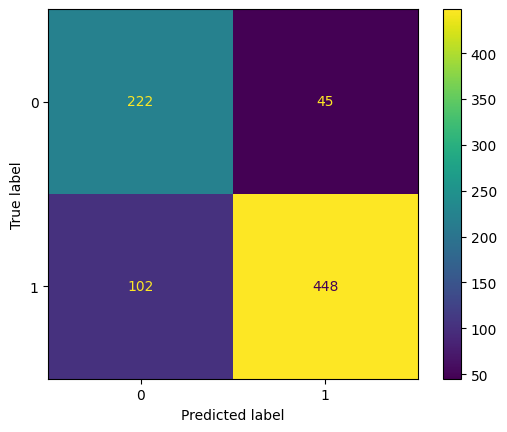

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(res, dataset.y_ind))
cm.plot()

In [12]:
import torch
print(torch.cuda.is_available())  # Should return True if CUDA is available
print(torch.__version__)  # Check your PyTorch version


True
2.3.1.post100


In [16]:
my_dict = {
    "act_fun": [F.gelu],
    "dropout_frac": [0.5],
    "patience": [100],
    "weight_decay": [1e-4],
    "n_epochs": [400],
    "neuron_layers": [[5000, 2500]]
    , "batch_size": [ 256]
    , "optimizer": [optim.RMSprop, optim.SGD] 
}


df_batch = test_fun(my_dict,dataset)

Device used: cuda
1 / 5
{'act_fun': <built-in function gelu>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 400, 'neuron_layers': [5000, 1024], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 100, 'weight_decay': 0.0001}
0.8563218390804598
2 / 5
{'act_fun': <built-in function gelu>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 400, 'neuron_layers': [2048, 1024, 512, 256, 128, 64, 32, 16, 8], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 100, 'weight_decay': 0.0001}
0.7526717557251908
3 / 5
{'act_fun': <built-in function gelu>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 400, 'neuron_layers': [4096, 2048, 1024, 512, 256], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 100, 'weight_decay': 0.0001}
0.8493683187560739
4 / 5
{'act_fun': <built-in function gelu>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 400, 'neuron_layers': [2048, 1024, 512, 256, 128, 64], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, '

In [20]:
from torch import optim
my_dict_ult = {
    "act_fun": [F.selu],
    "dropout_frac": [0, 0.25, 0.5],
    "patience": [50],
    "tol": [0, 1e-5],
    "weight_decay": [1e-4],
    "n_epochs": [200, 400, 1000],
    "neuron_layers": [[ 5000, 2500], [2048, 1024, 512, 256, 128, 64, 32, 16, 8],  [2048, 1024, 512, 256, 128, 64]]
    , "batch_size": [ 256]
    , "optimizer": [optim.RMSprop, optim.AdamW, optim.Adagrad] 
}
df_batch_ult = test_fun(my_dict_ult,dataset, X1, X2)

Device used: cuda
1 / 162
{'act_fun': <function selu at 0x7f06dedf16c0>, 'batch_size': 256, 'dropout_frac': 0, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 50, 'tol': 0, 'weight_decay': 0.0001}
0.8320158102766798
2 / 162
{'act_fun': <function selu at 0x7f06dedf16c0>, 'batch_size': 256, 'dropout_frac': 0, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 50, 'tol': 1e-05, 'weight_decay': 0.0001}
0.8333333333333334
3 / 162
{'act_fun': <function selu at 0x7f06dedf16c0>, 'batch_size': 256, 'dropout_frac': 0, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 50, 'tol': 0, 'weight_decay': 0.0001}
0.8408644400785854
4 / 162
{'act_fun': <function selu at 0x7f06dedf16c0>, 'batch_size': 256, 'dropout_frac': 0, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patien

In [25]:
df_batch_ult.sort_values(by="F1", ascending =False)

,act_fun,batch_size,dropout_frac,n_epochs,neuron_layers,optimizer,patience,tol,weight_decay,F1
95,<function selu at 0x7f06dedf16c0>,256,0.25,1000,"[5000, 2500]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00001,0.0001,0.854424
41,<function selu at 0x7f06dedf16c0>,256,0.00,1000,"[5000, 2500]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00001,0.0001,0.853868
68,<function selu at 0x7f06dedf16c0>,256,0.25,200,"[2048, 1024, 512, 256, 128, 64]",<class 'torch.optim.adamw.AdamW'>,50,0.00000,0.0001,0.851312
150,<function selu at 0x7f06dedf16c0>,256,0.50,1000,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]",<class 'torch.optim.rmsprop.RMSprop'>,50,0.00000,0.0001,0.850980
69,<function selu at 0x7f06dedf16c0>,256,0.25,200,"[2048, 1024, 512, 256, 128, 64]",<class 'torch.optim.adamw.AdamW'>,50,0.00001,0.0001,0.849075
...,...,...,...,...,...,...,...,...,...,...
29,<function selu at 0x7f06dedf16c0>,256,0.00,400,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00001,0.0001,0.008081
154,<function selu at 0x7f06dedf16c0>,256,0.50,1000,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00000,0.0001,0.000000
64,<function selu at 0x7f06dedf16c0>,256,0.25,200,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00000,0.0001,0.000000
136,<function selu at 0x7f06dedf16c0>,256,0.50,400,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]",<class 'torch.optim.adagrad.Adagrad'>,50,0.00000,0.0001,0.000000


In [28]:
test_par = {'weight_decay': 0.0001, 'patience': 1000, 
            'neuron_layers': [5000, 2500],
            'n_epochs': 1000, 'dropout_frac': 0.4,
            'act_fun': F.selu}
model_sts_3 = STFullyConnected(n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
dataset.X = dataset.X.fillna(value=0, inplace=True)
model_sts_3.fit(dataset.X, dataset.y)
res = model_sts_3.predict(dataset.X_ind)
res = res >0.5
print(f1_score(res, dataset.y_ind))

TypeError: new(): data must be a sequence (got NoneType)

In [30]:
test_par = {'weight_decay': 0.0001, 'patience': 400, 
            'neuron_layers': [5000, 2500],
            'n_epochs': 1000, 'dropout_frac': 0.4,
            'act_fun': F.selu}
model_sts_3 = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
model_sts_3.fit(X1, dataset.y)
res = model_sts_3.predict(X2)
res = res >0.5
print(f1_score(res, dataset.y_ind))

0.8366533864541833


In [31]:
from sklearn.metrics import accuracy_score 
print(accuracy_score ( res , dataset . y_ind ) )

0.799265605875153
